https://www.learnpytorch.io/

# Convolutional Neural Network

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Importing the libraries

In [1]:
import pandas as pd
import numpy as np
import torch as torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import os

In [ ]:
torch.__version__

'2.10.0+cu128'

## Part 1 - Data Preprocessing

### Preprocessing the Training set

### Define Transformations

First, we'll define transformations to apply to our images. This typically includes resizing, converting to a PyTorch tensor, and normalizing the pixel values. Normalization is crucial for neural networks. Normalization helps the optimization algorithm (like Adam) converge faster during training. Without it, different input features (pixel channels in this case) might have very different scales, leading to slow and unstable training.

In [7]:
# Define transformations for the training set
# The subsequent Normalize transformation after transforms.ToTensor() then further adjusts these [0, 1] values based on the specified mean and std to achieve a distribution closer to a mean of 0 and a standard deviation of 1, which is often beneficial for model training.
mnist_transforms = transforms.Compose([
    transforms.ToTensor(),       # Convert images to PyTorch tensors (scales to [0, 1])
    transforms.Normalize((.1307,),(.3081)) # Normalize with ImageNet stats
])

### Load the Dataset

Next, we'll use `torchvision.datasets.ImageFolder` to load your dataset. This function expects your data to be organized into subfolders, where each subfolder represents a class (e.g., `training_set/cats`, `training_set/dogs`).

### Loading the MNIST Dataset (PyTorch)

We will now download and load the MNIST training and test datasets. PyTorch's `torchvision.datasets.MNIST` makes this straightforward.

In [8]:
# Load MNIST training dataset
mnist_train_dataset = torchvision.datasets.MNIST(root='./data',
                                               train=True,
                                               download=True,
                                               transform=mnist_transforms)

# Load MNIST test dataset
mnist_test_dataset = torchvision.datasets.MNIST(root='./data',
                                              train=False,
                                              download=True,
                                              transform=mnist_transforms)

print(f"MNIST training set size: {len(mnist_train_dataset)}")
print(f"MNIST test set size: {len(mnist_test_dataset)}")

MNIST training set size: 60000
MNIST test set size: 10000


### Create a DataLoader

Finally, we'll create a `DataLoader` to iterate over the dataset in batches, shuffle the data, and handle multi-threading for efficient loading.

In [9]:
# Create DataLoader for MNIST training set
mnist_train_loader = DataLoader(
    mnist_train_dataset,
    batch_size=64, # Common batch size for MNIST
    shuffle=True,
    num_workers=os.cpu_count()
)

# Create DataLoader for MNIST test set
mnist_test_loader = DataLoader(
    mnist_test_dataset,
    batch_size=64,
    shuffle=False, # No need to shuffle test data
    num_workers=os.cpu_count()
)

print(f"Number of batches in MNIST training loader: {len(mnist_train_loader)}")
print(f"Number of batches in MNIST test loader: {len(mnist_test_loader)}")

Number of batches in MNIST training loader: 938
Number of batches in MNIST test loader: 157


### Visualize Sample Images from MNIST Training Set

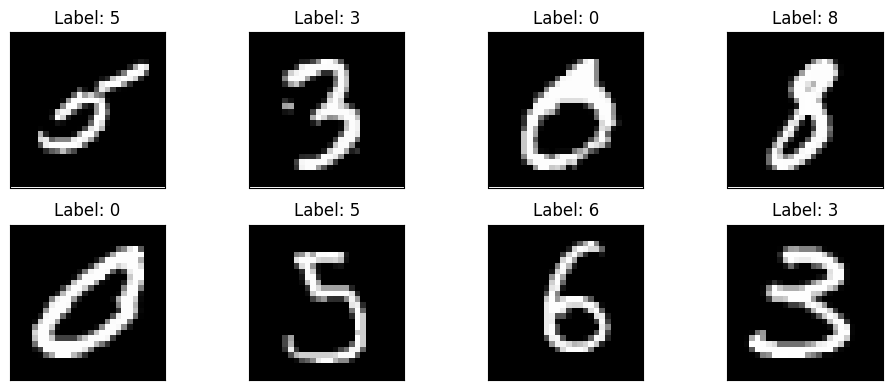

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch of training images and labels
dataiter = iter(mnist_train_loader)
images, labels = next(dataiter)

# Move images to CPU for visualization if they are on GPU
images = images.cpu()

# Unnormalize the images (reverse the normalization used during transform)
# For MNIST, mean = 0.1307, std = 0.3081
mean = 0.1307
std = 0.3081
images = images * std + mean

# Convert images to numpy array for matplotlib
images_np = images.numpy()

# Plot a few images
fig = plt.figure(figsize=(10, 4))
for idx in np.arange(8):
    ax = fig.add_subplot(2, 4, idx+1, xticks=[], yticks=[])
    # MNIST images are grayscale, so we squeeze the channel dimension
    ax.imshow(np.squeeze(images_np[idx]), cmap='gray')
    ax.set_title(f"Label: {labels[idx].item()}")
plt.tight_layout()
plt.show()


## Part 2 - Building the CNN (PyTorch Version)

### Define the CNN Architecture

In PyTorch, you define your neural network by subclassing `torch.nn.Module`. Your `__init__` method will define the layers, and the `forward` method will define how data flows through these layers.

In [11]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # First convolutional layer and pooling
        # MNIST images are 1 channel (grayscale)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # Second convolutional layer (after first pooling, input size remains 32 channels)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)
        # Fully connected layers
        # MNIST 28x28 -> pool (14x14) -> pool (7x7)
        # Input to fc1: 32 channels * 7x7 spatial dimensions
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        # Output layer for 10 classes (digits 0-9)
        self.fc2 = nn.Linear(128, 10)
        # Dropout layer
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        # Apply first convolution, ReLU, and pooling
        x = self.pool(F.relu(self.conv1(x)))
        # Apply second convolution, ReLU, and pooling
        x = self.pool(F.relu(self.conv2(x)))
        # Flatten the output for the fully connected layers
        x = x.view(-1, 32 * 7 * 7) # -1 infers batch size
        # Apply first fully connected layer, ReLU, and then Dropout
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        # Apply output layer (no activation here, handled by loss function like CrossEntropyLoss)
        x = self.fc2(x)
        return x

### Instantiate the Model and Move to Device

Now, let's create an instance of our CNN and check if a GPU is available to move the model and data to it for faster computation.

In [12]:
# Instantiate the CNN
model = SimpleCNN()

# Check for GPU and move model to it
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Model instantiated and moved to: {device}")
print(model)

Model instantiated and moved to: cuda
SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


## Part 3 - Training the CNN (PyTorch Version)

### Define Loss Function and Optimizer

For binary classification, `BCEWithLogitsLoss` is a common choice as it combines a sigmoid layer and the binary cross-entropy loss in one stable function. For the optimizer, Adam is a popular and effective choice.

In [15]:
import torch.optim as optim

# Define loss function (for multi-class classification)
criterion = nn.CrossEntropyLoss()

# Define optimizer with weight_decay for L2 regularization
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001) # Added weight_decay

print("Loss function and optimizer defined with L2 regularization.")

Loss function and optimizer defined with L2 regularization.


### Training Loop

The training loop involves iterating over a number of epochs. In each epoch, we iterate through the `train_loader`, get batches of images and labels, perform a forward pass, calculate the loss, perform backpropagation, and update the model's parameters.

In [16]:
import torch

if torch.cuda.is_available():
    print("GPU is available! Device name:", torch.cuda.get_device_name(0))
    print("Number of GPUs available:", torch.cuda.device_count())
else:
    print("GPU is not available. Running on CPU.")

GPU is available! Device name: Tesla T4
Number of GPUs available: 1


In [17]:
num_epochs = 50 # You can adjust this number

for epoch in range(num_epochs):
    model.train() # Set the model to training mode
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(mnist_train_loader): # Changed to mnist_train_loader
        inputs, labels = inputs.to(device), labels.to(device)

        # For CrossEntropyLoss, labels should be LongTensor and not unsqueezed
        # labels = labels.float().unsqueeze(1) # Removed for multi-class

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels) # CrossEntropyLoss expects raw logits

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Print statistics after each epoch
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(mnist_train_loader):.4f}")

print("Training complete!")

Epoch 1/50, Loss: 0.2396
Epoch 2/50, Loss: 0.0874
Epoch 3/50, Loss: 0.0657
Epoch 4/50, Loss: 0.0545
Epoch 5/50, Loss: 0.0478
Epoch 6/50, Loss: 0.0400
Epoch 7/50, Loss: 0.0378
Epoch 8/50, Loss: 0.0355
Epoch 9/50, Loss: 0.0318
Epoch 10/50, Loss: 0.0303
Epoch 11/50, Loss: 0.0277
Epoch 12/50, Loss: 0.0274
Epoch 13/50, Loss: 0.0251
Epoch 14/50, Loss: 0.0245
Epoch 15/50, Loss: 0.0228
Epoch 16/50, Loss: 0.0226
Epoch 17/50, Loss: 0.0213
Epoch 18/50, Loss: 0.0213
Epoch 19/50, Loss: 0.0198
Epoch 20/50, Loss: 0.0198
Epoch 21/50, Loss: 0.0183
Epoch 22/50, Loss: 0.0191
Epoch 23/50, Loss: 0.0189
Epoch 24/50, Loss: 0.0171
Epoch 25/50, Loss: 0.0187
Epoch 26/50, Loss: 0.0155
Epoch 27/50, Loss: 0.0168
Epoch 28/50, Loss: 0.0167
Epoch 29/50, Loss: 0.0179
Epoch 30/50, Loss: 0.0155
Epoch 31/50, Loss: 0.0168
Epoch 32/50, Loss: 0.0143
Epoch 33/50, Loss: 0.0172
Epoch 34/50, Loss: 0.0153
Epoch 35/50, Loss: 0.0154
Epoch 36/50, Loss: 0.0140
Epoch 37/50, Loss: 0.0146
Epoch 38/50, Loss: 0.0151
Epoch 39/50, Loss: 0.

### Accuracy Calculation

To assess the model's performance, we can calculate its accuracy on the training data. This involves making predictions and comparing them to the true labels.

In [18]:
model.eval() # Set the model to evaluation mode
correct = 0
total = 0

with torch.no_grad(): # Disable gradient calculation for inference
    for inputs, labels in mnist_train_loader: # Changed to mnist_train_loader
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        # For multi-class classification, get the class with the highest score
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy on the training set: {accuracy:.2f}%")

Accuracy on the training set: 99.93%


## Part 4 - Evaluating the CNN on the Test Set (PyTorch Version)

To ensure your model generalizes well, we need to evaluate its performance on a dataset it has not seen during training. This is called the test set.

### Evaluate Model on Test Set

Now, let's put the trained model into evaluation mode and calculate its accuracy on the test set. This process is very similar to how we calculated training accuracy.

In [19]:
model.eval() # Set the model to evaluation mode
correct_test = 0
total_test = 0

with torch.no_grad(): # Disable gradient calculation for inference
    for inputs, labels in mnist_test_loader: # Changed to mnist_test_loader
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        # For multi-class classification, get the class with the highest score
        _, predicted = torch.max(outputs.data, 1)

        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

test_accuracy = 100 * correct_test / total_test
print(f"Accuracy on the test set: {test_accuracy:.2f}%")

if test_accuracy < 90:
    print("\nNote: The test accuracy seems quite low compared to the training accuracy. This might indicate overfitting. Consider techniques like dropout, more data augmentation, or a simpler model to address this.")
else:
    print("\nYour model performed well on the test set! It generalizes effectively.")

Accuracy on the test set: 99.28%

Your model performed well on the test set! It generalizes effectively.


## Part 4 - Making a single prediction